# Modelo de Hodgkin y Huxley

# Cálculo de Curvas f-I

Este notebook tiene como objetivo calcular las curvas $ f-I $ (frecuencia-corriente), así como aprender a hacer análisis de tiempos de disparo.

### Ejercicio 1:

Construir la curva f-I del modelo de HH con los parámetros dados en la clase anterior. A qué tipo de clase de excitabilidad corresponde el modelo de HH con los parámetros estudiados?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

In [2]:
# Datos Simulación taller 1:
def alpha_n(Vm):
  return 0.01*(Vm+55)/(1-np.exp(-(Vm+55)/10))

def beta_n(Vm):
  return 0.125*np.exp(-(Vm+65)/80)

def alpha_m(Vm):
  return 0.1*(Vm+40)/(1-np.exp(-(Vm+40)/10))

def beta_m(Vm):
  return 4*np.exp(-(Vm+65)/18)

def alpha_h(Vm):
  return 0.07*np.exp(-(Vm+65)/20)

def beta_h(Vm):
  return 1/(1+np.exp(-(Vm+35)/10))

def Ina(Vm, m,h, g_Na, ENa):

  return g_Na*m**3*h*(Vm-ENa)

def Ik(Vm, n, g_K, EK):

  return g_K*n**4*(Vm-EK)

def Il(Vm, g_L, EL):

  return g_L*(Vm-EL)

def HodgkinHuxley(t, X, Cm, g_Na, ENa, g_K, EK, g_L, EL, Iext):
    Vm = X[0]
    m = X[1]
    h = X[2]
    n = X[3]

    Vp = (Iext - (Ina(Vm, m, h, g_Na, ENa) + Ik(Vm, n, g_K, EK) + Il(Vm, g_L, EL)))/Cm
    mp = alpha_m(Vm)*(1-m) - beta_m(Vm)*m
    hp = alpha_h(Vm)*(1-h) - beta_h(Vm)*h
    np = alpha_n(Vm)*(1-n) - beta_n(Vm)*n

    return [Vp, mp, hp, np]


# Función que nos permitirá iterar para cada corriente.

def solucion(Iext):
  # Parámetros:
  Cm = 1
  tspan = [0,1000]
  V0 = -65
  m0 = alpha_m(V0)/(alpha_m(V0)+beta_m(V0))
  h0 = alpha_h(V0)/(alpha_h(V0)+beta_h(V0))
  n0 = alpha_n(V0)/(alpha_n(V0)+beta_n(V0))
  X0 = [V0,m0,h0,n0]
  g_Na = 120 # Conductancia máxima Na
  ENa = 50 # Potencial de equilibrio de sodio.
  g_K = 36 # Conductancia máxima K
  EK = -77 # Potencial de equilibrio de potasio.
  g_L = 0.3 # Conductancia máxima L
  EL = -50 # Potencial de equilibrio de fuga.

  # Calculamos la aproximación
  solucion = solve_ivp(HodgkinHuxley,tspan,X0,args=(Cm,g_Na, ENa, g_K, EK, g_L, EL,Iext,),dense_output=True, atol = 1e-6, rtol = 1e-6)

  # Calculamos los resultados.
  t = solucion.t
  Vm,m,h,n = solucion.y

  """  # Graficamos

  plt.subplot(2,1,1)
  plt.plot(t,Vm)
  plt.xlabel('tiempo (ms)')
  plt.ylabel('Vm')
  plt.plot(t,-65*np.ones(len(t)))
  plt.title('Potencial de membrana')
  plt.legend(['Vm','Vrest'])"""

  # Hacemos tdenso para mejor precisión
  tdenso = np.linspace(tspan[0],tspan[1],20000)
  Vm,m,h,n = solucion.sol(tdenso)

  # Encontrar picos pero solo mayores que 0 (es decir, que si sean spikes):
  peakID,_ = find_peaks(Vm, height=0)

  # Evaluar los tiempos y los valores
  tiempos_spikes = tdenso[peakID]
  valores_spikes = Vm[peakID]

  """
  # Graficar la aproximación con los picos.
  plt.subplot(2,1,2)
  plt.plot(tdenso,Vm,'.')
  plt.plot(tiempos_spikes,valores_spikes,'o')
  plt.xlabel('tiempo [ms]')
  plt.ylabel('Vm')
  plt.show()
  print("Corriente: ", Iext)
  print("Numero de spikes: ",len(tiempos_spikes))"""

  # Si no hay picos suficientes para promediar:
  if len(peakID) <2:
    return 0

  # Calcular el ISI promedio y la frecuencia de disparo:
  T_entre_spikes = np.diff(tiempos_spikes)
  T = np.mean(T_entre_spikes)
  Frecuencia_spikes = 1/T
  return Frecuencia_spikes

In [3]:
# Calcular con las corrientes cada frecuencia:
Corrientes = np.linspace(0,10,50)
Frecuencias = np.array([solucion(i) for i in Corrientes])
# Pasar de kHz a Hz:
Frecuencias = Frecuencias*1000

Text(0.5, 1.0, 'Curva f-I')

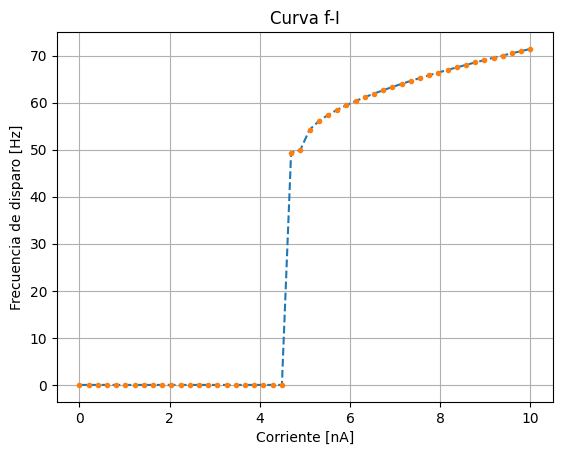

In [4]:
# Graficar:
plt.plot(Corrientes,Frecuencias,"--")
plt.plot(Corrientes,Frecuencias,".")
plt.grid()
plt.xlabel('Corriente [nA]')
plt.ylabel('Frecuencia de disparo [Hz]')
plt.title('Curva f-I')

Se concluye que la neurona que modelamos es de tipo II.

### Ejercicio 2:

A continuación se le presenta un experimento real de electorfisología en el que su colega biólogo ha hecho un experimento aplicando un protocolo de estimulación a una neurona, consistente en varios valores de corriente constante. Su colega le solicita que le indique si la neurona que ha registrado es de tipo I o tipo II.

Realice el análisis para determinarlo. Para ello

1. Compute la curva $f - I$ de esta neurona
2. Muestre dos curvas representativas mostrando cómo es la traza de tiempo del voltaje para una corriente subumbral y una supraumbral.


El dipsoitivo que se usa para hacer registros electrofisiológicos almacena los datos en formato *abf*, para poder leer los datos ejecute el siguiente *snippet*

In [5]:
!pip install pyabf
import pyabf
abf = pyabf.ABF('SpikesAndBursts_PFC_Pvalb_APs_01.abf')
print(abf)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.0 MB/s eta 0:00:00
ABF (v2.6) with 2 channels (mV, pA), sampled at 10.0 kHz, containing 13 sweeps, having no tags, with a total length of 0.65 minutes, recorded with protocol "CC_20pA_100_340pA_500ms".


Como puede notar el objeto abf importado contiene información sobre 2 canales. Uno mide el potencial de membrana, mientras el otro registra la corriente aplicada, ambas en función del tiempo, con una frecuencia de muestreo de 10kHz. El experimento consiste en 13 *sweeps* o protocolos diferentes. Para acceder a la información del *sweep* i-ésimo, deberá llamar el método

abf.setSweep(i)

Una vez establecido el sweep que desea analizar la información requerida la encontrará en los siguiente atributos:

- tiempo -> abf.sweepX
- voltaje -> abf.sweepY
- corriente -> abf.sweepC

## Recorriendo los 13 Sweep para comprender su funcionamiento.

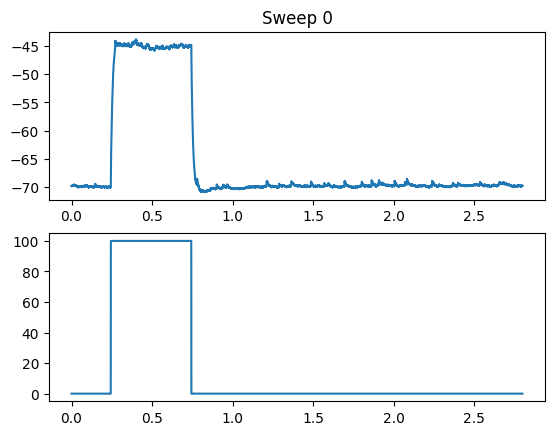

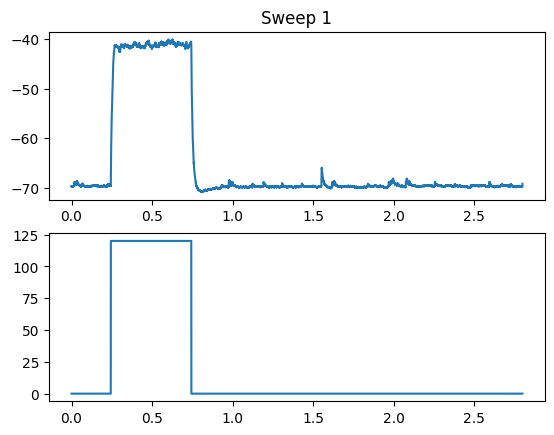

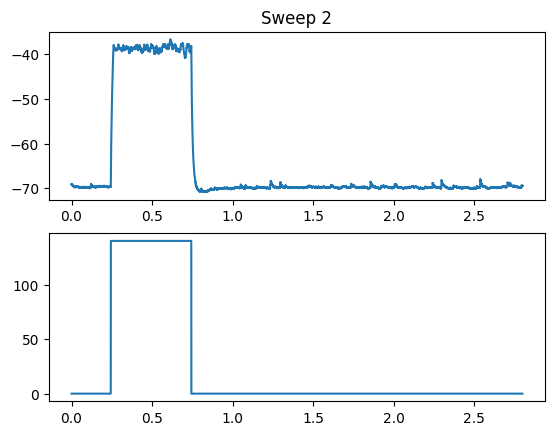

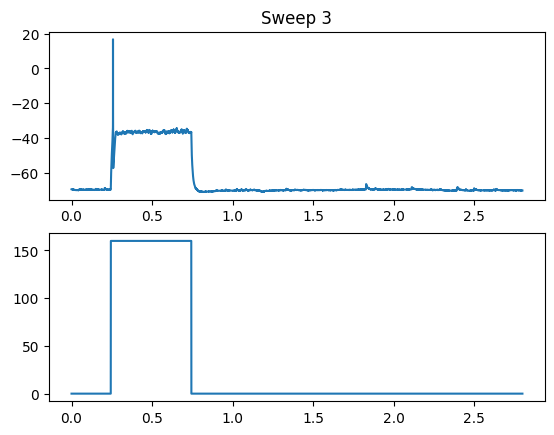

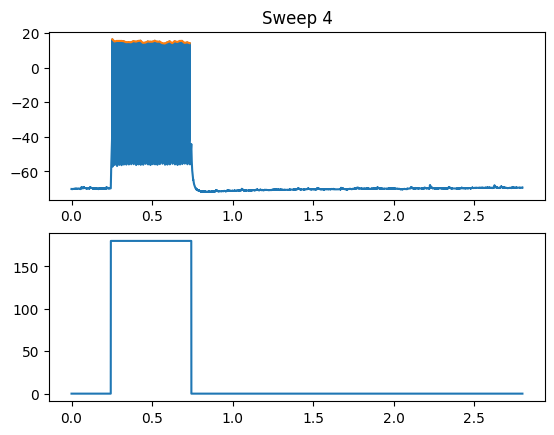

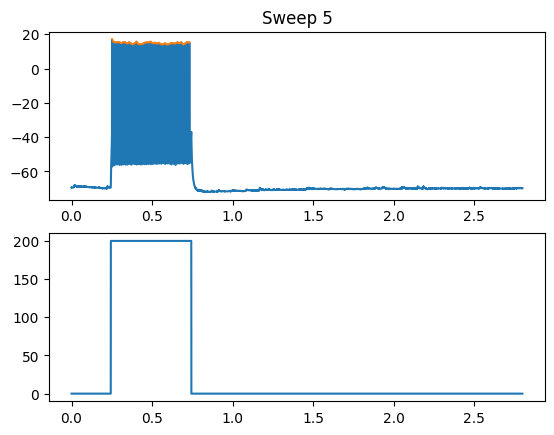

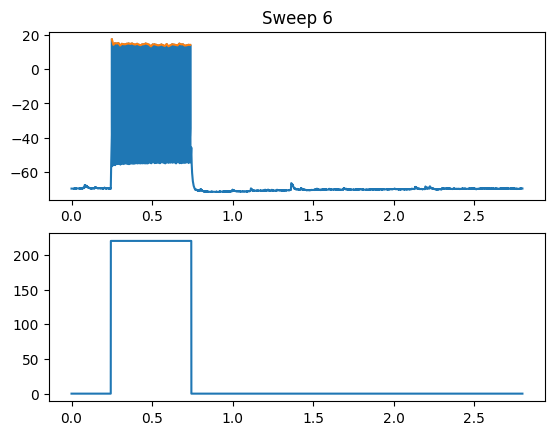

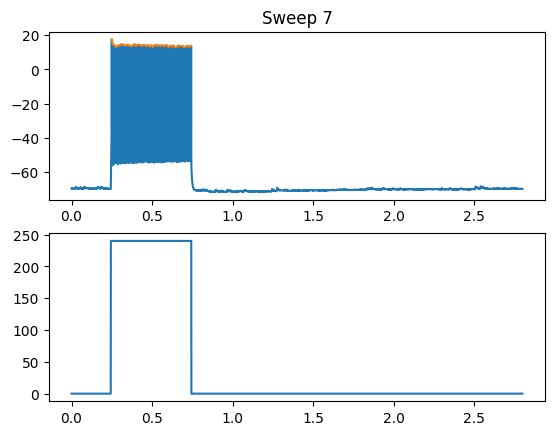

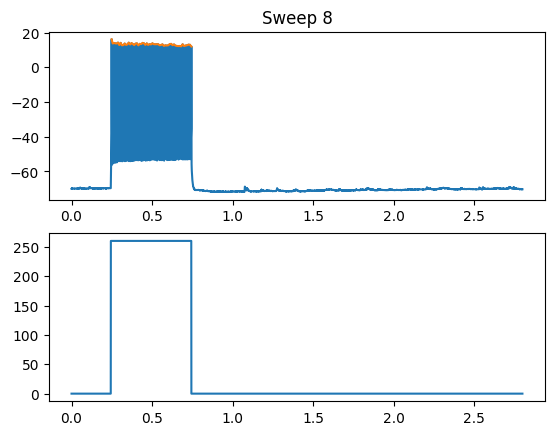

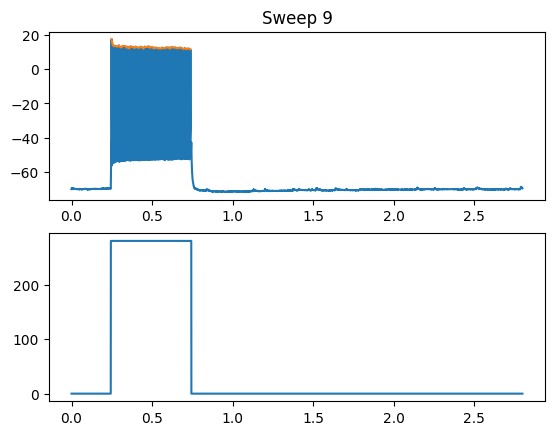

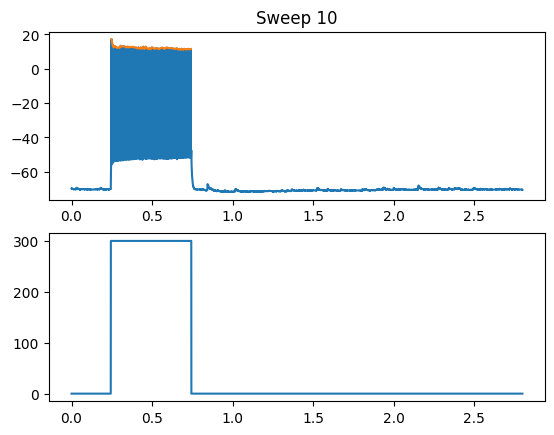

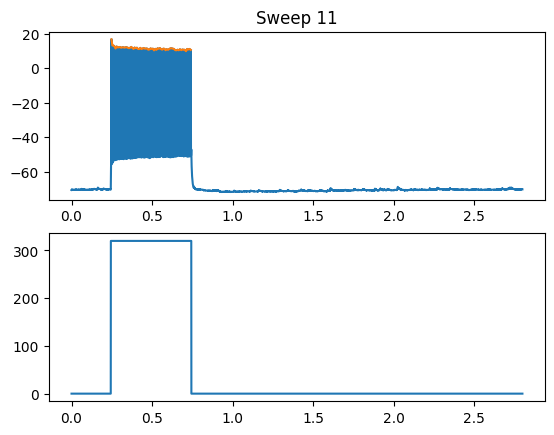

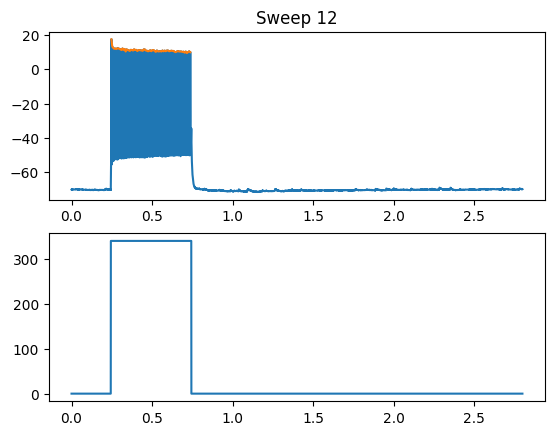

In [6]:
for x in range(13):
  abf.setSweep(x)
  tiempo = abf.sweepX
  Vm = abf.sweepY
  corriente = abf.sweepC

  peakID,_ = find_peaks(Vm, height=0)
  tiempos_spikes = tiempo[peakID]
  valores_spikes = Vm[peakID]


  plt.subplot(2,1,1)
  plt.title(f"Sweep {x}")
  plt.plot(tiempo,Vm)
  plt.plot(tiempos_spikes,valores_spikes)
  plt.subplot(2,1,2)
  plt.plot(tiempo,corriente)
  plt.show()

## Solución

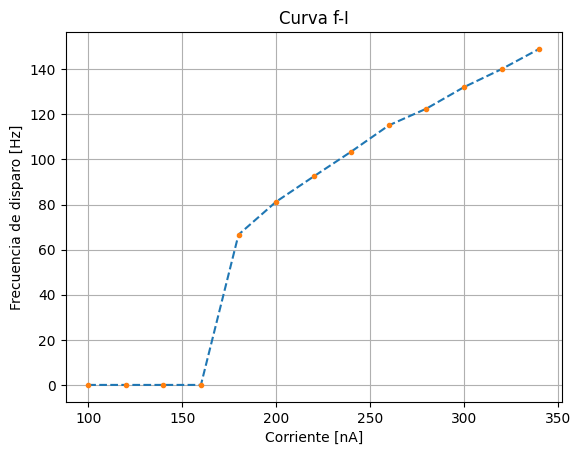

In [7]:
# Creamos los arrays en los que vamos a almacenar.
Frecuencias = np.zeros(13)
Corrientes = np.zeros(13)

# Recorremos a Sweep (experimento con diferente corriente).
for x in range(13):
  abf.setSweep(x) # Cargamos el Sweep
  tiempo = abf.sweepX # Tiempo
  Vm = abf.sweepY # Potencial de membrana
  corriente = abf.sweepC # Corriente externa.

  # Encontramos los picos y los respectivos tiempos.
  peakID,_ = find_peaks(Vm, height=0)
  tiempos_spikes = tiempo[peakID]
  valores_spikes = Vm[peakID]

  # En caso de que no hayan picos suficientes para promediar.
  if len(peakID) <2:
    Frecuencias[x] = 0
  else:
    # Calcular el ISI promedio y la frecuencia de disparo:
    T_entre_spikes = np.diff(tiempos_spikes)
    T = np.mean(T_entre_spikes)
    Frecuencia_spikes = 1/T
    # Agregamos los valores del experimento.
    Frecuencias[x] = Frecuencia_spikes
  Corrientes[x] = max(corriente) # Corriente continua aplicada diferente de 0

# Graficamos.
plt.plot(Corrientes,Frecuencias,"--")
plt.plot(Corrientes,Frecuencias,".")
plt.grid()
plt.xlabel('Corriente [nA]')
plt.ylabel('Frecuencia de disparo [Hz]')
plt.title('Curva f-I')
plt.show()

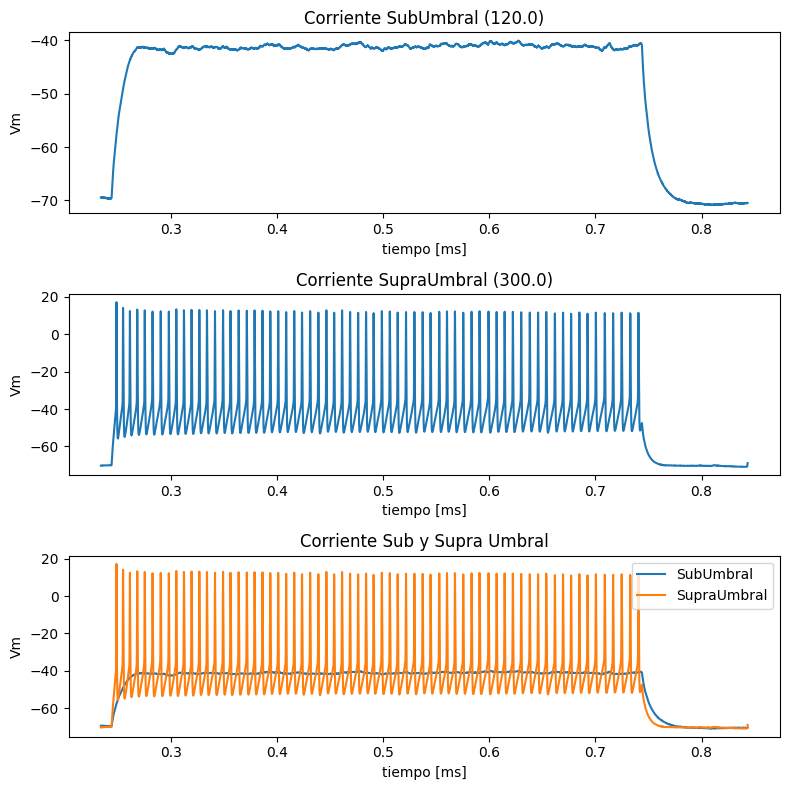

In [8]:
# Corriente SupUmbral (Sweep 1 de 13.)
abf.setSweep(1)
tiempo = abf.sweepX
Vm = abf.sweepY
corriente = abf.sweepC

# Calculamos en que tiempos se aplica corriente.
tiempo_ini = min(tiempo[corriente>0])
tiempo_fin = max(tiempo[corriente>0])

corriente_supUmbral = max(corriente) # Corriente aplicada.

# Tiempo y potencial de membrana obtenido.
tiempo_con_corrienteSub = tiempo[(tiempo>tiempo_ini-0.01) & (tiempo<tiempo_fin+0.1)]
Vm_con_corrienteSub = Vm[(tiempo>tiempo_ini-0.01) & (tiempo<tiempo_fin+0.1)]

# Corriente SupraUmbral (Sweep 10 de 13.)
abf.setSweep(10)
tiempo = abf.sweepX
Vm = abf.sweepY
corriente = abf.sweepC

# Calculamos en que tiempos se aplica corriente.
tiempo_ini = min(tiempo[corriente>0])
tiempo_fin = max(tiempo[corriente>0])

corriente_supraUmbral = max(corriente) # Corriente aplicada.

# Tiempo y potencial de membrana obtenido.
tiempo_con_corriente10 = tiempo[(tiempo>tiempo_ini-0.01) & (tiempo<tiempo_fin+0.1)]
Vm_con_corriente10 = Vm[(tiempo>tiempo_ini-0.01) & (tiempo<tiempo_fin+0.1)]


# Graficamos ambos resultados y una comparación entre las dos.
plt.figure(figsize=(8,8))
plt.subplot(3,1,1)
plt.plot(tiempo_con_corrienteSub,Vm_con_corrienteSub)
plt.xlabel('tiempo [ms]')
plt.ylabel('Vm')
plt.title(f'Corriente SubUmbral ({corriente_supUmbral})')

plt.subplot(3,1,2)
plt.plot(tiempo_con_corriente10,Vm_con_corriente10)
plt.xlabel('tiempo [ms]')
plt.ylabel('Vm')
plt.title(f'Corriente SupraUmbral ({corriente_supraUmbral})')

plt.subplot(3,1,3)
plt.plot(tiempo_con_corrienteSub,Vm_con_corrienteSub)
plt.plot(tiempo_con_corriente10,Vm_con_corriente10)
plt.xlabel('tiempo [ms]')
plt.ylabel('Vm')
plt.title('Corriente Sub y Supra Umbral')
plt.legend(['SubUmbral','SupraUmbral'])
plt.tight_layout()
plt.show()

Debido al salto tan fuerte en la curva f-I, concluimos que la neurona estudiada es del tipo II.